Hola **Paul**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para mantener buenas prácticas y una correcta presentación de tus notebooks te recomiendo siempre dejar al inico en una celda markdown un título descriptivo al proyecto con una breve introducción al mismo
</div>

### 1. Procesamiento, Limpieza y Exploración (EDA)

#### 1.1. Carga de datos

In [1]:
# Carga de librerias
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datasets
df_contract = pd.read_csv('/datasets/final_provider/contract.csv')
df_personal = pd.read_csv('/datasets/final_provider/personal.csv')
df_internet = pd.read_csv('/datasets/final_provider/internet.csv')
df_phone = pd.read_csv('/datasets/final_provider/phone.csv')

#### 1.2. Unión de datasets (merge)

In [2]:
# Uniremos los archivos en un solo dataset con merge, usando 'customerID' como referencia
df_full = df_contract.merge(df_personal, on='customerID', how='left')
df_full = df_full.merge(df_internet, on='customerID', how='left')
df_full = df_full.merge(df_phone, on='customerID', how='left')

In [3]:
df_full

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,1990.5,Male,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7362.9,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,Yes,Yes,DSL,Yes,No,No,No,No,No,NaN
7041,8361-LTMKD,2019-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,74.40,306.6,Male,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes


#### 1.3. Estandarización de nombre de columnas 'snake_case'

In [4]:
# Estandarizaremos el nombre de las columnas con formato 'snake_case' para un mejor entendimiento y procesamiento. Esto lo haremos mediante una función que identificará la separación de palabras detectando, por medio de Expresiones Regulares (RegEx) una mayúscula seguida de una minúscula e insertará un guión bajo, además de convertir todo el texto a minúsculas.
def to_snake_case(name):
    return re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', name).lower()

df_full.columns = [to_snake_case(col) for col in df_full.columns]

df_full.info()
df_full

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   begin_date         7043 non-null   object 
 2   end_date           7043 non-null   object 
 3   type               7043 non-null   object 
 4   paperless_billing  7043 non-null   object 
 5   payment_method     7043 non-null   object 
 6   monthly_charges    7043 non-null   float64
 7   total_charges      7043 non-null   object 
 8   gender             7043 non-null   object 
 9   senior_citizen     7043 non-null   int64  
 10  partner            7043 non-null   object 
 11  dependents         7043 non-null   object 
 12  internet_service   5517 non-null   object 
 13  online_security    5517 non-null   object 
 14  online_backup      5517 non-null   object 
 15  device_protection  5517 non-null   object 
 16  tech_support       5517 

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,1990.5,Male,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7362.9,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,Yes,Yes,DSL,Yes,No,No,No,No,No,NaN
7041,8361-LTMKD,2019-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,74.40,306.6,Male,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes


#### 1.4. Limpieza de datos, cambios de tipos de datos y manejo de valores nulos o duplicados

In [5]:
# Contamos el total de valores nulos en el dataset
print(f"Total de valores nulos en el dataset: {df_full.isnull().sum().sum()}")

# Contamos el total de filas duplicadas en el dataset
print(f"Total de filas duplicadas exactas: {df_full.duplicated().sum()}")

# Identificamos que el dtype de la columna 'total_charges' está como object en lugar de float64
print(f"Tipo de dato de columna 'total_charges': {df_full['total_charges'].dtype}")

# Identificamos que el contenido que las columnas 'begin_date' y 'end_date' no tienen formato de fecha
print(f"Tipo de dato de columna 'begin_date': {df_full['begin_date'].dtype}")
print(f"Tipo de dato de columna 'end_date': {df_full['end_date'].dtype}")

Total de valores nulos en el dataset: 11364
Total de filas duplicadas exactas: 0
Tipo de dato de columna 'total_charges': object
Tipo de dato de columna 'begin_date': object
Tipo de dato de columna 'end_date': object


In [6]:
# Manejo de valores nulos en servicios que se generaron por el 'merge' que hicimos en clientes que no tienen esos servicios. Rellenaremos con 'No'.
columnas_servicios = ['internet_service', 'online_security', 'online_backup', 
                      'device_protection', 'tech_support', 'streaming_tv', 
                      'streaming_movies', 'multiple_lines']

df_full[columnas_servicios] = df_full[columnas_servicios].fillna('No')

print(f"Total de valores nulos en el dataset: {df_full.isnull().sum().sum()}")

Total de valores nulos en el dataset: 0


In [7]:
# Corrección de tipos de datos en columna 'total_charges' de object a float y reemplazamos con '0' en caso de que haya algún espacio vacío para indicar que no hay cargo.
df_full['total_charges'] = df_full['total_charges'].replace(' ', 0) 
df_full['total_charges'] = pd.to_numeric(df_full['total_charges'])

# Convertimos 'begin_date' de texto (object) a formato de fecha (datetime)
df_full['begin_date'] = pd.to_datetime(df_full['begin_date'], format='%Y-%m-%d')
print(f"Tipo de dato de columna 'begin_date': {df_full['begin_date'].dtype}")

Tipo de dato de columna 'begin_date': datetime64[ns]


**Nota:** A pesar de que la columna 'end_date' tampoco está con formato date_time, la dejaremos así por lo pronto, ya que contiene la palabra 'No', indicanto que el usuario aún está activo. Más adelante indicaré como procesaremos ésos datos.

#### 1.5. Ingeniería de características (target y antigüedad)

In [8]:
# Creamos un columna llamada 'churn', derivada de la columna 'end_date' donde indicaremos como valores 1 si canceló o 0 si sigue activo tomando en cuenta el valor 'No'.
df_full['churn'] = (df_full['end_date'] != 'No').astype(int)
df_full

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,churn
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,...,No,DSL,No,Yes,No,No,No,No,No,0
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.50,Male,0,...,No,DSL,Yes,No,Yes,No,No,No,No,0
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,No,DSL,Yes,Yes,No,No,No,No,No,1
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,...,No,DSL,Yes,No,Yes,Yes,No,No,No,0
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,Fiber optic,No,No,No,No,No,No,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,1990.50,Male,0,...,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,0
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7362.90,Female,0,...,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,0
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,...,Yes,DSL,Yes,No,No,No,No,No,No,0
7041,8361-LTMKD,2019-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,74.40,306.60,Male,1,...,No,Fiber optic,No,No,No,No,No,No,Yes,1


In [9]:
# Calcularemos la antigüedad en días (tenure_days) usando la fecha de corte indicada (01-Feb-2020) para los que tienen 'No'. Para el cálculo usaremos una columna temporal 'end_date_temp'.
df_full['end_date_temp'] = df_full['end_date'].replace('No', '2020-02-01')

# Forzamos errors='coerce' para manejar sin problemas las fechas con '00:00:00'
df_full['end_date_temp'] = pd.to_datetime(df_full['end_date_temp'], errors='coerce')

# Calculamos la diferencia en días
df_full['tenure_days'] = (df_full['end_date_temp'] - df_full['begin_date']).dt.days

# Eliminamos la columna temporal
df_full = df_full.drop(['end_date_temp'], axis=1)

df_full.info()
df_full

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   object        
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   gender             7043 non-null   object        
 9   senior_citizen     7043 non-null   int64         
 10  partner            7043 non-null   object        
 11  dependents         7043 non-null   object        
 12  internet_service   7043 non-null   object        
 13  online_security    7043 non-null   object        
 14  online_b

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,churn,tenure_days
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,...,DSL,No,Yes,No,No,No,No,No,0,31
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.50,Male,0,...,DSL,Yes,No,Yes,No,No,No,No,0,1036
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,DSL,Yes,Yes,No,No,No,No,No,1,61
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,...,DSL,Yes,No,Yes,Yes,No,No,No,0,1371
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,Fiber optic,No,No,No,No,No,No,No,1,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,1990.50,Male,0,...,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,0,730
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7362.90,Female,0,...,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,0,2191
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,...,DSL,Yes,No,No,No,No,No,No,0,337
7041,8361-LTMKD,2019-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,74.40,306.60,Male,1,...,Fiber optic,No,No,No,No,No,No,Yes,1,123


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, asegurar la calidad de los datos es un paso vital cuando se trata de entrenar modelos de ML, ya que esto asegura que el análisis y los entrenamientos sean adecuados para la toma de decisiones más adelante.
</div>

#### 1.6. Análisis Exploratorio de Datos (EDA)

##### 1.6.1 Representación Visual del Negocio (Variables Numéricas)

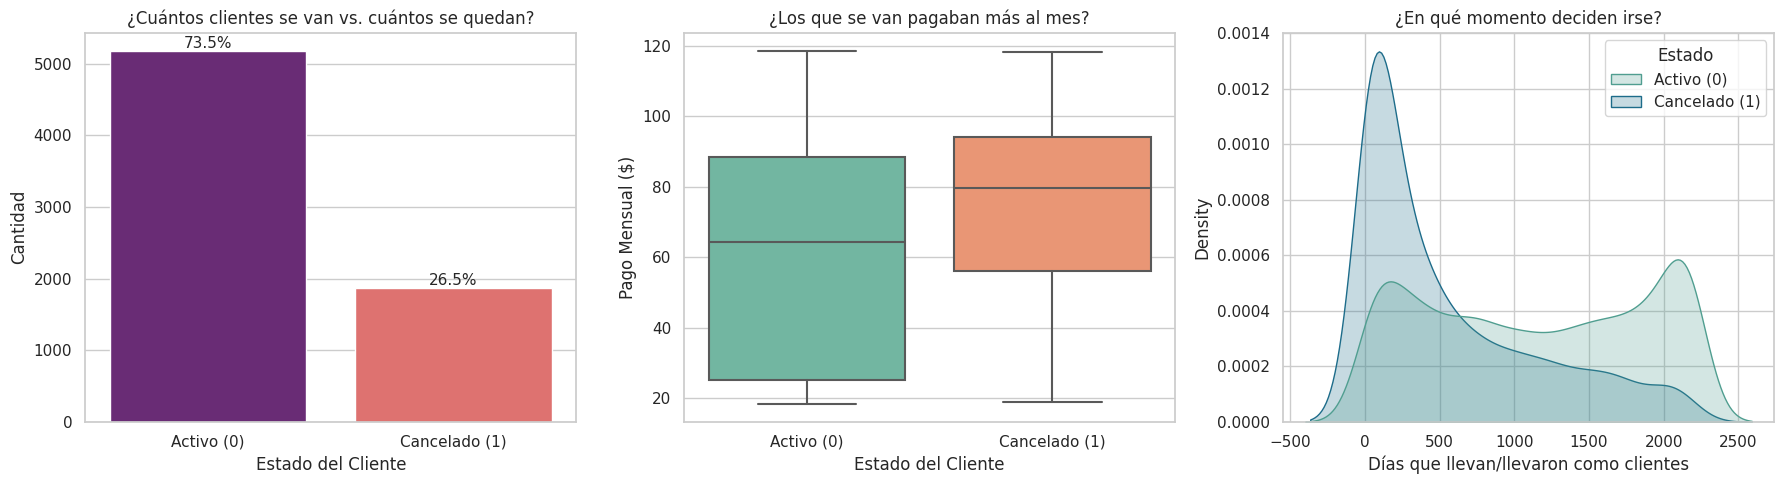

In [10]:
# Importar librerías
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Definir estilo de gráficas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Definir etiquetas de 'churn' como Activo si es 0 y Cancelado si es 1 para facilitar su entendimiento
churn_labels = df_full['churn'].map({0: 'Activo (0)', 1: 'Cancelado (1)'})

# Balance de Clases
sns.countplot(x=churn_labels, palette='magma', ax=axes[0], order=['Activo (0)', 'Cancelado (1)'])
axes[0].set_title('¿Cuántos clientes se van vs. cuántos se quedan?')
axes[0].set_xlabel('Estado del Cliente')
axes[0].set_ylabel('Cantidad')

total_clientes = len(df_full)
for p in axes[0].patches:
    pct = f'{100 * p.get_height() / total_clientes:.1f}%'
    axes[0].annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=11)

# Distribución de Cargos Mensuales
sns.boxplot(x=churn_labels, y=df_full['monthly_charges'], palette='Set2', ax=axes[1], order=['Activo (0)', 'Cancelado (1)'])
axes[1].set_title('¿Los que se van pagaban más al mes?')
axes[1].set_xlabel('Estado del Cliente')
axes[1].set_ylabel('Pago Mensual ($)')

# Densidad de Antigüedad
sns.kdeplot(data=df_full, x='tenure_days', hue=churn_labels, fill=True, common_norm=False, palette='crest', ax=axes[2])
axes[2].set_title('¿En qué momento deciden irse?')
axes[2].set_xlabel('Días que llevan/llevaron como clientes')
axes[2].get_legend().set_title("Estado")

plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, siempre en problemas de clasificación lo primero que se debe revisar es el balance de la variable objetivo ya que según esto se deben aplicar diferentes procesos para que los modelos logren tener un buen desempeño de las predicciones para cada caso sin importar el balance.
</div>

In [11]:
# Resumen estadístico
total_clientes = len(df_full)
total_activos = len(df_full[df_full['churn'] == 0])
total_cancelados = len(df_full[df_full['churn'] == 1])

pct_activos = (total_activos / total_clientes) * 100
pct_cancelados = (total_cancelados / total_clientes) * 100

print(f"RESUMEN GLOBAL:")
print(f"- Total de clientes analizados: {total_clientes}")
print(f"- Clientes que se mantienen ACTIVOS: {total_activos} ({pct_activos:.1f}%)")
print(f"- Clientes que han CANCELADO: {total_cancelados} ({pct_cancelados:.1f}%)")

date_min_begin = df_full['begin_date'].min().date()
date_max_begin = df_full['begin_date'].max().date()
print(f"\nMARCO TEMPORAL:")
print(f"- Los contratos más antiguos iniciaron el: {date_min_begin}")
print(f"- Los contratos más recientes iniciaron el: {date_max_begin}")

cancelados_df = df_full[df_full['end_date'] != 'No'].copy()
cancelados_df['end_date'] = pd.to_datetime(cancelados_df['end_date'], errors='coerce')
print(f"- Las cancelaciones registradas ocurrieron entre el {cancelados_df['end_date'].min().date()} y el {cancelados_df['end_date'].max().date()}")

stats_activos = df_full[df_full['churn'] == 0][['monthly_charges', 'tenure_days']].describe().round(2)
stats_cancelados = df_full[df_full['churn'] == 1][['monthly_charges', 'tenure_days']].describe().round(2)

print("\nDATOS DE CLIENTES QUE SIGUEN ACTIVOS (0):")
display(stats_activos.T)

print("\nDATOS DE CLIENTES QUE CANCELARON (1):")
display(stats_cancelados.T)

RESUMEN GLOBAL:
- Total de clientes analizados: 7043
- Clientes que se mantienen ACTIVOS: 5174 (73.5%)
- Clientes que han CANCELADO: 1869 (26.5%)

MARCO TEMPORAL:
- Los contratos más antiguos iniciaron el: 2013-10-01
- Los contratos más recientes iniciaron el: 2020-02-01
- Las cancelaciones registradas ocurrieron entre el 2019-10-01 y el 2020-01-01

DATOS DE CLIENTES QUE SIGUEN ACTIVOS (0):


,count,mean,std,min,25%,50%,75%,max
monthly_charges,5174.0,61.27,31.09,18.25,25.1,64.43,88.4,118.75
tenure_days,5174.0,1144.45,733.90,0.00,457.0,1157.00,1857.0,2191.00



DATOS DE CLIENTES QUE CANCELARON (1):


,count,mean,std,min,25%,50%,75%,max
monthly_charges,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35
tenure_days,1869.0,547.35,594.39,30.00,61.00,304.00,883.0,2191.00



**Conclusiones de las Variables Numéricas:**
- Hay un evidente desbalanceo de la variable objetivo (*churn*). En la primera gráfica podemos ver que muchos más clientes activos (73.5%) que cancelados (26.5%), lo que requerirá realizar técnicas de balanceo en nuestro modelo predictivo.
- La media del gasto total por mes de los que cancelan es considerablemente más alta que de los que se encuentran activos, como se muestra en el segundo gráfico, lo que indica que el factor económico es una razón de fuga. La mediana de un cliente activo es de $64.43, mientras que canceló es de $79.65.
- El gráfico de densidad muestra un patrón de mayor cancelaciones durante los primeros meses de contratado el servicio. La antigüedad promedio de un cliente activo es de 1,145 días contra los 547 días de un cliente que cancela. Esto indica que la lealtad del cliente es algo a tomar en cuenta en nuestro análisis.
- La empresa ha tenido 7,043 clientes, ha estado operando entre 2013 y 2020.
- Descubrimos que la tasa de *churn* es del 26.5%.
- En el resumen estadístico podemos constatar que no hay valores atípicos, además de dar información importante como el promedio, la mediana, cuartiles, etc. 


##### 1.6.2 Detalle por Servicios y Contratos (Variables Categóricas)

In [12]:
# Hacemos unas tablas donde comparamos las variables categóricas con el estado del cliente (Activo o Cancelado)

cat_cols = ['type', 'internet_service', 'payment_method', 'online_security']
for col in cat_cols:
    print(f"\nANÁLISIS DE COLUMNA: {col.upper()}")
    tabla = pd.crosstab(df_full[col], churn_labels, margins=True, margins_name="Total")
    for c in ['Activo (0)', 'Cancelado (1)']:
        pct = (tabla[c] / tabla['Total'] * 100).round(1).astype(str) + '%'
        tabla[c] = tabla[c].astype(str) + " (" + pct + ")"
    display(tabla)


ANÁLISIS DE COLUMNA: TYPE


churn,Activo (0),Cancelado (1),Total
type,,,
Month-to-month,2220 (57.3%),1655 (42.7%),3875
One year,1307 (88.7%),166 (11.3%),1473
Two year,1647 (97.2%),48 (2.8%),1695
Total,5174 (73.5%),1869 (26.5%),7043



ANÁLISIS DE COLUMNA: INTERNET_SERVICE


churn,Activo (0),Cancelado (1),Total
internet_service,,,
DSL,1962 (81.0%),459 (19.0%),2421
Fiber optic,1799 (58.1%),1297 (41.9%),3096
No,1413 (92.6%),113 (7.4%),1526
Total,5174 (73.5%),1869 (26.5%),7043



ANÁLISIS DE COLUMNA: PAYMENT_METHOD


churn,Activo (0),Cancelado (1),Total
payment_method,,,
Bank transfer (automatic),1286 (83.3%),258 (16.7%),1544
Credit card (automatic),1290 (84.8%),232 (15.2%),1522
Electronic check,1294 (54.7%),1071 (45.3%),2365
Mailed check,1304 (80.9%),308 (19.1%),1612
Total,5174 (73.5%),1869 (26.5%),7043



ANÁLISIS DE COLUMNA: ONLINE_SECURITY


churn,Activo (0),Cancelado (1),Total
online_security,,,
No,3450 (68.7%),1574 (31.3%),5024
Yes,1724 (85.4%),295 (14.6%),2019
Total,5174 (73.5%),1869 (26.5%),7043


**Conclusiones de las Variables Categóricas:**
- El esquema 'Month-to-Month' concentra la mayoría de las cancelaciones.
- Los usuarios con Fibra Óptica cancelan más que los de DSL. Esto sugiere un problema operativo (fallas técnicas) o precios poco competitivos.
- Los clientes que no cuentan con el servicio de Online Security muestran una tasa de abandono mayor, lo que lo convierte en un servicio clave a tomar en cuenta.

##### 1.6.3 Análisis de Datos Demográficos y Otros Servicios

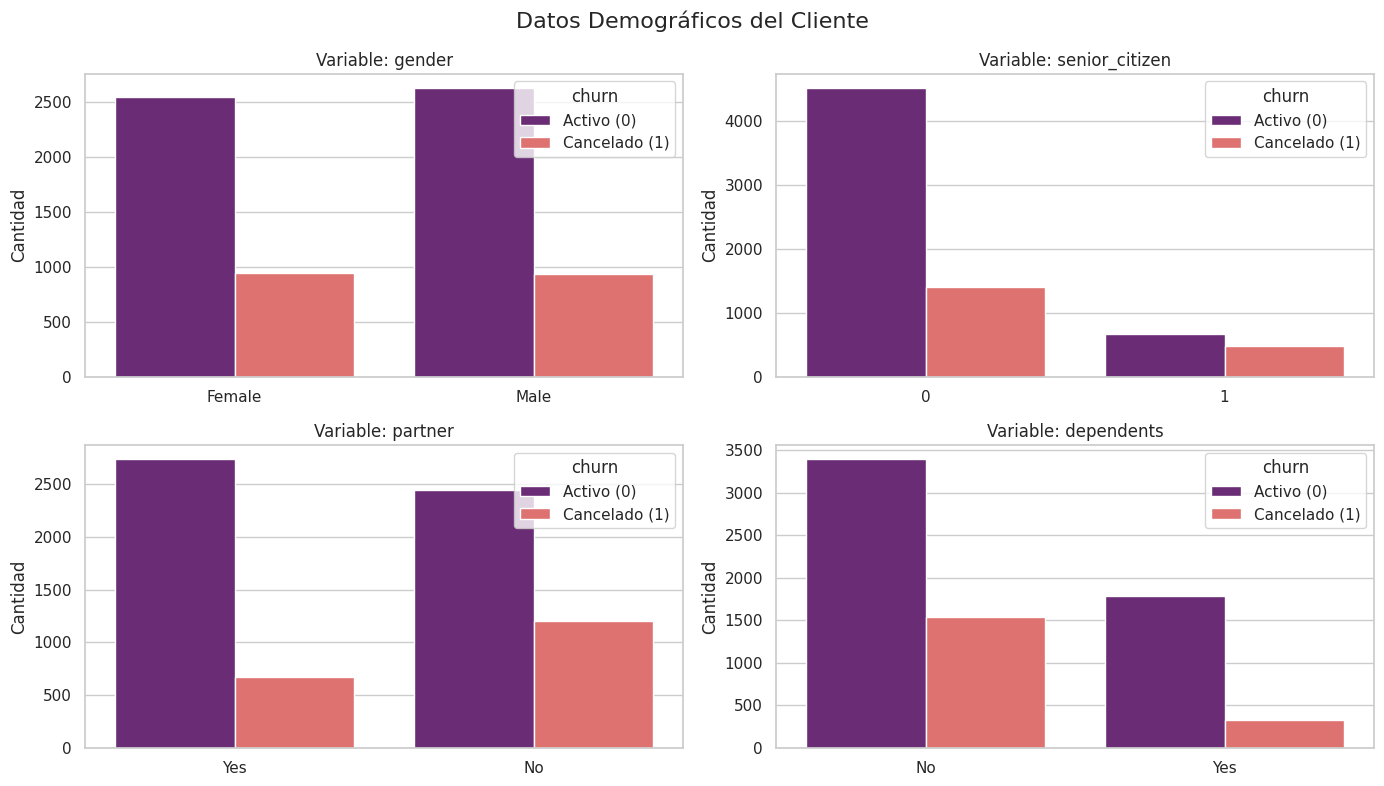

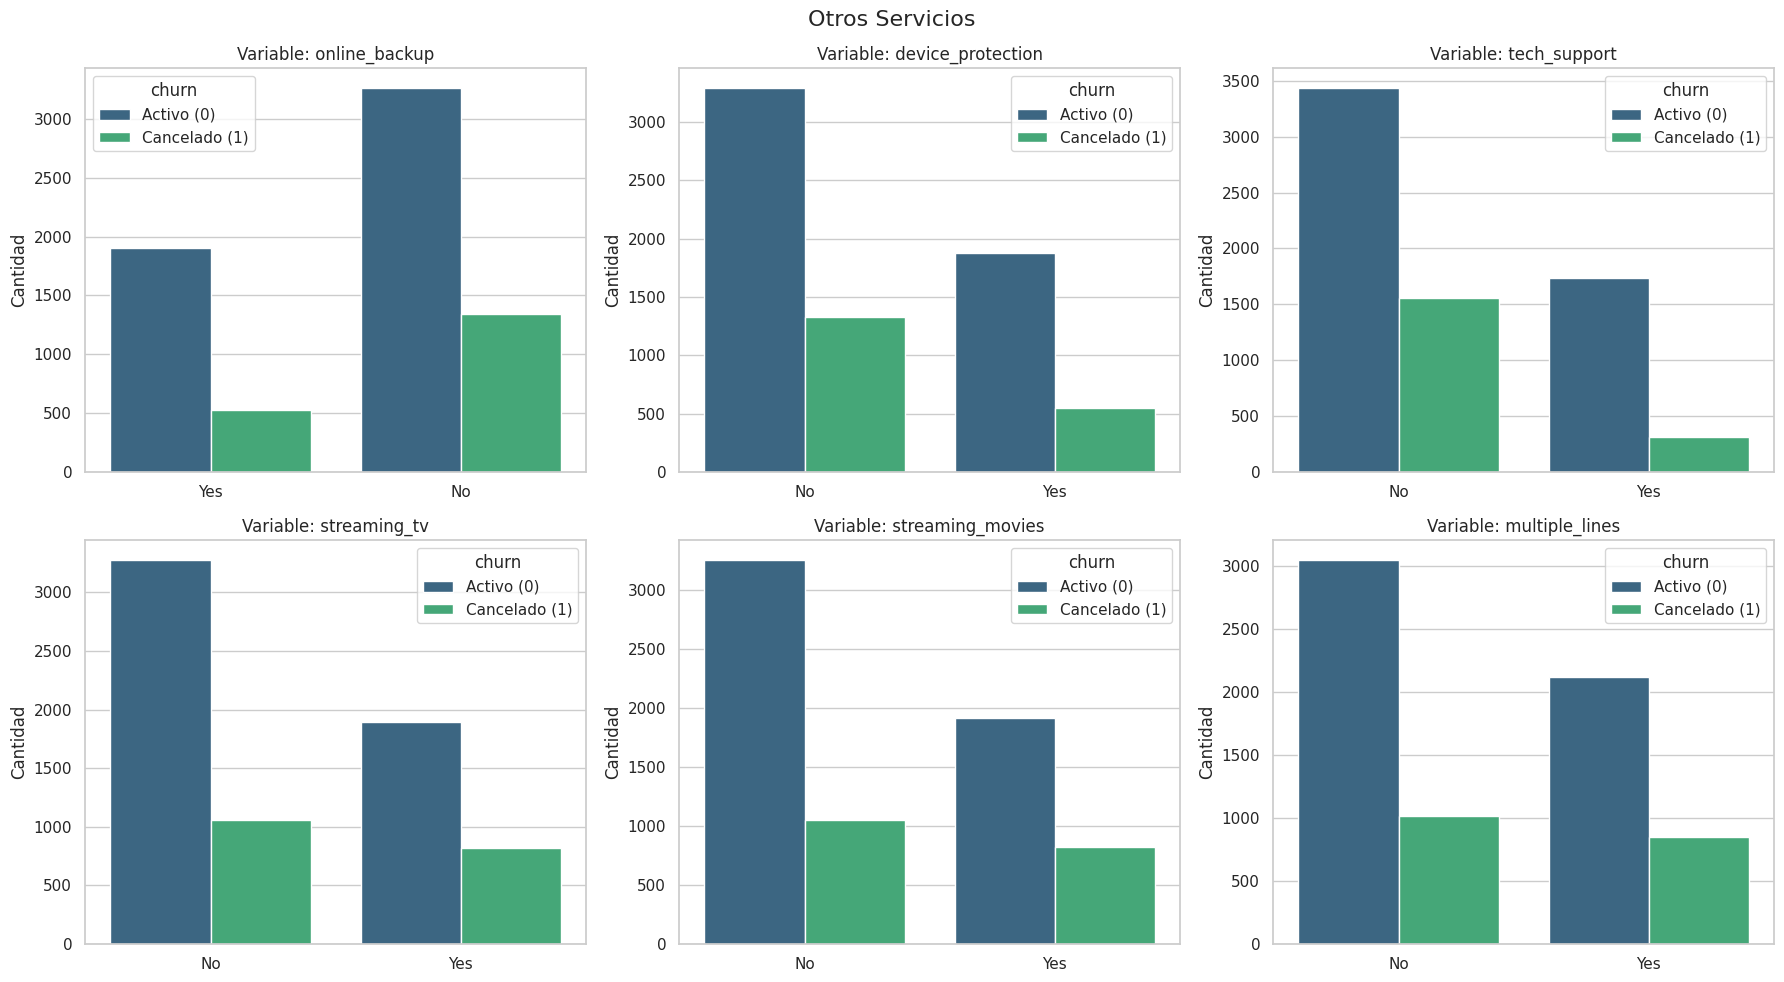

In [13]:

# Datos Demográficos
demo_cols = ['gender', 'senior_citizen', 'partner', 'dependents']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Datos Demográficos del Cliente', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    sns.countplot(data=df_full, x=demo_cols[i], hue=churn_labels, palette='magma', ax=ax)
    ax.set_ylabel('Cantidad')
    ax.set_xlabel('')
    ax.set_title(f"Variable: {demo_cols[i]}")

plt.tight_layout()
plt.show()

# 2. Otros Servicios
otros_servicios = ['online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Otros Servicios', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    sns.countplot(data=df_full, x=otros_servicios[i], hue=churn_labels, palette='viridis', ax=ax)
    ax.set_ylabel('Cantidad')
    ax.set_xlabel('')
    ax.set_title(f"Variable: {otros_servicios[i]}")

plt.tight_layout()
plt.show()

**Conclusiones de datos demográficos y otros servicios:**

- Decidí no incluir éstos datos en las comparativas anteriores porque se cae mucho en la redundancia. Hay resultados muy parecidos y, en este momento, no creo que sean de valor para el análisis. Sin embargo, más adelante, haremos un análisis de colinealidad para constatar que en verdad sean datos redundantes que no aporten a nuestro modelo.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto el proceso de EDA, se analizaron las variables con gráficas adecuadas y siempre redactando tu interpretación lo cual ayuda a dejar un proceso de análisis claro y fácil de seguir en el notebook que vas a presentar de tu proyecto.
</div>

### 2. Preparación de datos para el modelo

#### 2.1. Análisis de Colinealidad

El análisis de colinealidad lo dividiré en 3 fases:
- **Fase 1 "sentido común":** Definiremos las variables que, por sentido común de Machine Learning, no son de valor para nuestro modelo.
- **Fase 2 "variables numéricas":** Evaluaremos las variables numéricas mediante un mapa de calor.
- **Fase 3 "variables categóricas":** Revisaremos las variables categóricas mediante *One-Heat Coding* y un gráfico de barras de correlación.

##### 2.1.1 Fase 1 "Sentido Común"

**Variables a eliminar:**
- ***customer_id:*** Genera ruido y riesgo de overfitting, no aporta información valiosa a nuestro modelo ya que sólo es un identificador del cliente.
- ***begin_date y end_date:*** Los modelos que usaremos no procesan formatos de fecha. Además, la columna *end_date* integra la variable que queremos predecir. De ambas columnas ya extrajimos los datos que ocuparemos en nuestro modelo: *churn* y *tenure_days*.

##### 2.1.2 Fase 2 "Variables Numéricas"

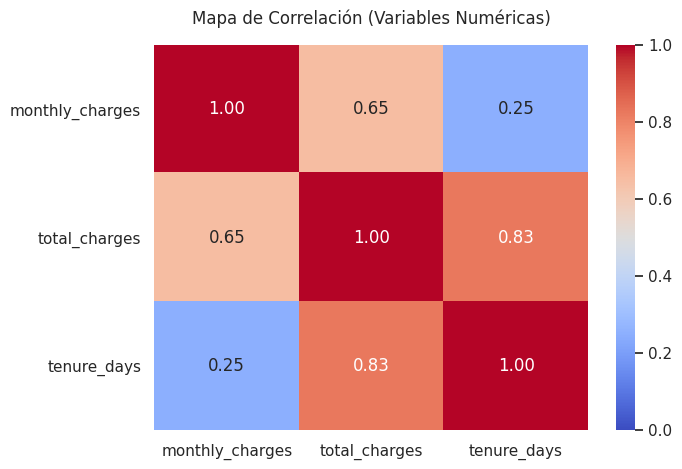

In [14]:
# Importamos librerías
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos exclusivamente las variables numéricas para buscar colinealidad
num_cols = ['monthly_charges', 'total_charges', 'tenure_days']
matriz_corr = df_full[num_cols].corr()

# Mapa de calor
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.title('Mapa de Correlación (Variables Numéricas)', pad=15)
plt.show()

**Variables a eliminar:**
- ***total_charges:*** El mapa de calor nos indica que hay una fuerte correlación postivia de 0.83 entre la antigüedad del cliente (*tenure_days*) y el cargo total (*total_charges*), estos se debe a que los cargos totales son datos producto del tiempo por la mensualidad.

**¿Porqué no eliminar *tenure_days*?** 
Porque en el desarrollo del EDA descubrimos que la antigüedad del cliente es un factor importante en su decisión de mantenerse activo. Además, estos datos no son dependientes de alguna otra variable que estemos considerando usar en nuestro modelo.

##### 2.1.3 Fase 3 "Variables Categóricas"

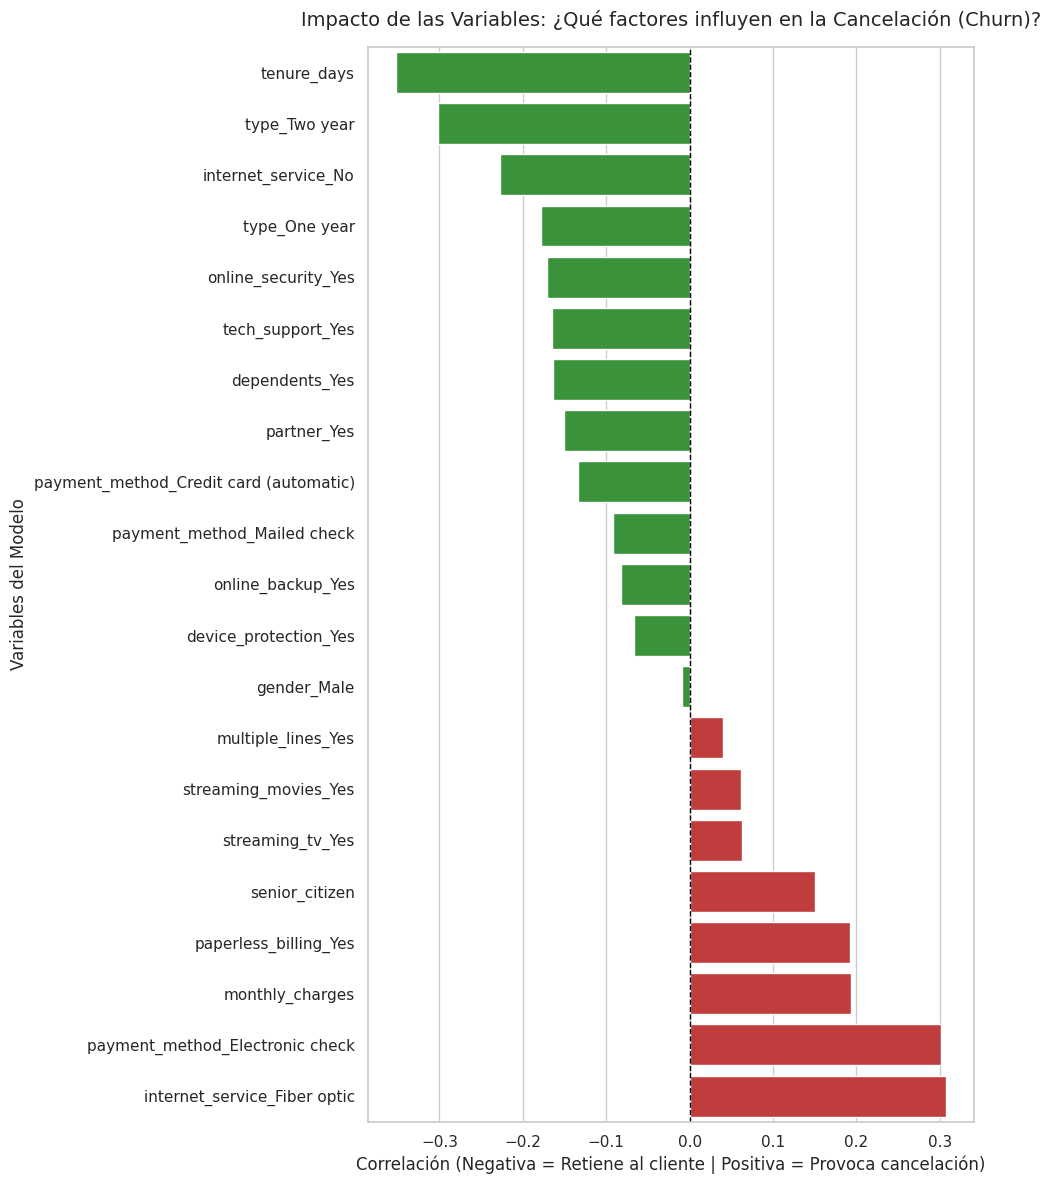

In [15]:
# Para medir el impacto, tomamos df_full y quitamos el target y las columnas que son ruido
columnas_a_ignorar = ['customer_id', 'begin_date', 'end_date', 'total_charges', 'churn']
X_temporal = df_full.drop(columns=columnas_a_ignorar)
y_target = df_full['churn']

# drop_first=True evita crear columnas redundantes
X_encoded_grafica = pd.get_dummies(X_temporal, drop_first=True)

# Unimos temporalmente para calcular la correlación global
df_analisis = X_encoded_grafica.copy()
df_analisis['churn'] = y_target

# Calculamos y ordenamos las correlaciones
correlaciones = df_analisis.corr()['churn'].drop('churn').sort_values()

# Generamos el gráfico de barras de impacto
plt.figure(figsize=(10, 12))
colores = ['#2ca02c' if x < 0 else '#d62728' for x in correlaciones]
sns.barplot(x=correlaciones.values, y=correlaciones.index, palette=colores)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Impacto de las Variables: ¿Qué factores influyen en la Cancelación (Churn)?', fontsize=14, pad=15)
plt.xlabel('Correlación (Negativa = Retiene al cliente | Positiva = Provoca cancelación)')
plt.ylabel('Variables del Modelo')

plt.tight_layout()
plt.show()

**Correlación Negativa (Barras Verdes):** Las barras que crecen a la izquierda tienen una correlación negativa con la cancelación, esto significa que si ésta característica está presente el riesgo de fuga (*churn*) disminuye.

**Correlación Positiva (Barras Rojas):** Las barras que crecen hacia la derecha tienen una correlación positiva con la cancelación, esto significa que si la característica está presente, el riesgo de que el cliente se vaya aumenta.

Decidí **no eliminar variables categóricas** porque pueden esconder algún patrón oculto que se puede descubrir al momento de correr nuestros modelos más complejos. A pesar de que al tener un valor bajo, parezca que no influyen.

#### 2.2. Selección de features y separación del target

In [16]:
# Aplicamos la eliminación definitiva de variables justificadas
columnas_a_eliminar = ['customer_id', 'begin_date', 'end_date', 'total_charges']
df_model = df_full.drop(columns=columnas_a_eliminar)

# Separamos las características (X) de la variable objetivo (y)
X = df_model.drop('churn', axis=1)
y = df_model['churn']

print(f"Dataset original: {df_full.shape}")
print(f"Dataset después de la selección de features: {df_model.shape}")
print(f"Forma de la matriz de características (X): {X.shape}")
print(f"Forma del vector objetivo (y): {y.shape}")

# Verificamos las columnas que sobrevivieron
print("\nVariables que entrarán al proceso de entrenamiento:")
print(X.columns.tolist())

print("\n ===== DATASET FEATURES =====")
print(X.head())

print("\n ===== DATASET TARGET =====")
print(y.head())

Dataset original: (7043, 22)
Dataset después de la selección de features: (7043, 18)
Forma de la matriz de características (X): (7043, 17)
Forma del vector objetivo (y): (7043,)

Variables que entrarán al proceso de entrenamiento:
['type', 'paperless_billing', 'payment_method', 'monthly_charges', 'gender', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines', 'tenure_days']

 ===== DATASET FEATURES =====
             type paperless_billing             payment_method  \
0  Month-to-month               Yes           Electronic check   
1        One year                No               Mailed check   
2  Month-to-month               Yes               Mailed check   
3        One year                No  Bank transfer (automatic)   
4  Month-to-month               Yes           Electronic check   

   monthly_charges  gender  senior_citizen partner dependen

#### 2.3. Partición de datos

In [17]:
# Importamos librerías
from sklearn.model_selection import train_test_split

# Ejecutaremos una partición 80/20
# random_state=12345 usaremos el mismo corte
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=12345, stratify=y
)

print(" ===== PARTICIÓN DE DATOS (TRAIN / TEST) =====")
print(f"La matriz de características (X) original tenía: {X.shape[0]} filas.")
print("-" * 50)
print(f"Set de ENTRENAMIENTO (Train) - 80%: {X_train.shape[0]} filas.")
print(f"Set de PRUEBA (Test) - 20%: {X_test.shape[0]} filas.")
print("-" * 50)

# 2. Comprobación matemática de la estratificación
print("\nComprobando la proporción de cancelaciones (Clase 1):")
print(f"En todo el dataset: {(y.mean() * 100):.1f}%")
print(f"En Entrenamiento: {(y_train.mean() * 100):.1f}%")
print(f"En Prueba: {(y_test.mean() * 100):.1f}%")

 ===== PARTICIÓN DE DATOS (TRAIN / TEST) =====
La matriz de características (X) original tenía: 7043 filas.
--------------------------------------------------
Set de ENTRENAMIENTO (Train) - 80%: 5634 filas.
Set de PRUEBA (Test) - 20%: 1409 filas.
--------------------------------------------------

Comprobando la proporción de cancelaciones (Clase 1):
En todo el dataset: 26.5%
En Entrenamiento: 26.5%
En Prueba: 26.5%


**Notas:**
- Se aplicó una partición estándar de 80% para el conjunto de entrenamiento y 20% para el conjunto de prueba.
- Usando *stratify=y* se mantuvo la proporción de cancelaciones de 26.5% del dataset original en *train* y *test*.
- Aplicamos el mismo *random_state=12345* que usaremos en todo el proyecto.

#### 2.4. Transformación de variables

Usaremos *One-Heat Encoding* en las variables categóricas y escalaremos con *StandardScaler*

In [18]:
# Importamos librerías
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Aplicamos One-Hot Encoding (OHE) a las variables categóricas
# Se aplica tanto al set de entrenamiento como al de prueba
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Alineación de seguridad: Garantiza que Train y Test tengan exactamente las mismas columnas en el mismo orden
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [19]:
# Escalamiento de variables numéricas
cols_num = ['monthly_charges', 'tenure_days']
scaler = StandardScaler()

# Hacemos FIT (aprender la escala) SOLO en los datos de Entrenamiento
X_train_encoded[cols_num] = scaler.fit_transform(X_train_encoded[cols_num])

# En los datos de Prueba, SOLO hacemos TRANSFORM (usando lo que aprendió del Entrenamiento)
X_test_encoded[cols_num] = scaler.transform(X_test_encoded[cols_num])

print(f"Dimensiones finales para entrenar: {X_train_encoded.shape}")

display(X_train_encoded.head(5))

Dimensiones finales para entrenar: (5634, 21)


,monthly_charges,senior_citizen,tenure_days,type_One year,type_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,gender_Male,...,dependents_Yes,internet_service_Fiber optic,internet_service_No,online_security_Yes,online_backup_Yes,device_protection_Yes,tech_support_Yes,streaming_tv_Yes,streaming_movies_Yes,multiple_lines_Yes
1212,0.165477,0,-1.033811,0,0,1,0,1,0,1,...,0,1,0,0,0,0,0,0,0,0
3759,0.823991,0,-1.035145,0,0,1,1,0,0,1,...,0,1,0,0,0,1,0,1,0,1
4082,0.657700,0,0.670234,1,0,0,0,1,0,1,...,0,0,0,1,0,1,1,1,1,1
413,0.757475,0,0.751633,0,0,1,0,1,0,1,...,0,1,0,0,1,1,1,0,0,1
6805,1.362776,1,1.524258,1,0,1,0,0,0,0,...,0,1,0,0,1,0,1,1,1,1


**Notas:**
- Se aplicó *One-Heat Encoding* con *drop_first=True*, eliminando la primera variable categórica para no introducir redundancia al modelo.
- Las variables numéricas *monthly_charges* y *tenure_days* fueron escaladas usando *StandardScaler*.
- El ajuste de las escalas se restringió al conjunto de entrenamiento, aplicando únicamente la transformación al conjunto de prueba. Esto con el fin de prevenir el *Data Leakage*. 

### 3. Desarrollo de modelos (Clasificación)

#### 3.1. Prueba de cordura (Sanity Check)

In [20]:
# Importamos librerías
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# Inicializamos el modelo "dummy"
# strategy='most_frequent' le indica que siempre adivine la clase que más se repite (0 = Activo)
dummy_model = DummyClassifier(strategy='most_frequent')

# "Entrenamos" el modelo (realmente solo cuenta cuál clase es mayoritaria en y_train)
dummy_model.fit(X_train_encoded, y_train)

# Lo ponemos a hacer predicciones (X_test_encoded)
y_pred_dummy = dummy_model.predict(X_test_encoded)

# Evaluamos sus resultados
exactitud_dummy = accuracy_score(y_test, y_pred_dummy)

print(f"Exactitud (Accuracy) del modelo dummy: {exactitud_dummy * 100:.2f}%")
print("-" * 50)
print("Reporte de Clasificación del Modelo Dummy:\n")
# zero_division=0 evita que Python lance un error rojo porque el modelo nunca predice '1'
print(classification_report(y_test, y_pred_dummy, zero_division=0))

Exactitud (Accuracy) del modelo dummy: 73.46%
--------------------------------------------------
Reporte de Clasificación del Modelo Dummy:

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



**Notas:**
- Corrimos el modelo *dummy* para verificar el desbalanceo entre la clase 0 y 1, además de constatar que la métrica *Accuracy* no es totalmente fiable.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto, de esta forma se puede realizar la comparación del desempeño de los modelos de manera más fácil de entender. 

Te podría recomendar cómo adicional generar visualizaciones que ayuden a la interpretación del desempeño de los modelos.
</div>

#### 3.2. Modelo Base

##### 3.2.1 Logistic Regression

In [21]:
# Cargamos librerías
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, f1_score

# Inicializamos un diccionario donde guardaremos los resultados para usarlos en la comparativa final
if 'registro_modelos' not in locals():
    registro_modelos = {}

# Inicializamos el modelo base: LogisticRegression
modelo_base = LogisticRegression(random_state=12345, class_weight='balanced', max_iter=1000)

# Entrenamos el modelo
print("Entrenando Regresión Logística...")
modelo_base.fit(X_train_encoded, y_train)

# Calculamos probabilidades para ROC-AUC (Train y Test)
prob_base_train = modelo_base.predict_proba(X_train_encoded)[:, 1]
prob_base_test = modelo_base.predict_proba(X_test_encoded)[:, 1]

roc_auc_train = roc_auc_score(y_train, prob_base_train)
roc_auc_test = roc_auc_score(y_test, prob_base_test)

# Calculamos predicciones exactas para Recall y F1 (Solo en Test)
y_pred_base = modelo_base.predict(X_test_encoded)
recall_test = recall_score(y_test, y_pred_base)
f1_test = f1_score(y_test, y_pred_base)

# Guardamos en el registro
registro_modelos['Regresión Logística (Base)'] = {
    'ROC-AUC (Test)': roc_auc_test,
    'ROC-AUC (Train)': roc_auc_train,
    'Brecha (Overfitting)': roc_auc_train - roc_auc_test,
    'Recall (Test)': recall_test,
    'F1-Score (Test)': f1_test
}

print(f"✅ Entrenamiento completado exitosamente.")
print(f"Métrica Principal (ROC-AUC en Test): {roc_auc_test:.4f}")

Entrenando Regresión Logística...
✅ Entrenamiento completado exitosamente.
Métrica Principal (ROC-AUC en Test): 0.8344


**Notas:**
- El modelo de regresión logística ha logrado procesar exitosamente las variables transformadas.
- Con el uso del hiperparámetro *class_weight='balanced'* logramos que el *Recall* de la clase 1 (cancelaciones) del modelo *dummy* cambie de 0.00 a un resultado operativo real.
- Con la métrica *AUC-ROC* tenemos una mejor opción para evaluar el modelo que solamente usar *Accuracy*.
- Este modelo nos servirá como base de referencia para comparar con los resultados que obtendremos de los modelos más robustos.

#### 3.3. Modelos Avanzados

##### 3.3.1 Random Forest

In [22]:
# Cargamos librerías
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score

# Inicializamos y entrenamos el modelo
# Seguiremos usando class_weight='balanced' y random_state=12345
rf_model = RandomForestClassifier(random_state=12345, class_weight='balanced')

print("Entrenando el Bosque Aleatorio...")
rf_model.fit(X_train_encoded, y_train)

# Calculamos probabilidades (Train y Test) para medir el sobreajuste con ROC-AUC
prob_rf_train = rf_model.predict_proba(X_train_encoded)[:, 1]
prob_rf_test = rf_model.predict_proba(X_test_encoded)[:, 1]

roc_auc_train = roc_auc_score(y_train, prob_rf_train)
roc_auc_test = roc_auc_score(y_test, prob_rf_test)

# Calculamos las etiquetas exactas (0 y 1) en Test para el Recall y F1
y_pred_rf = rf_model.predict(X_test_encoded)
recall_test = recall_score(y_test, y_pred_rf)
f1_test = f1_score(y_test, y_pred_rf)

# Guardamos las 4 métricas en nuestro registro oficial
registro_modelos['Random Forest (Sin Optimizar)'] = {
    'ROC-AUC (Test)': roc_auc_test,
    'ROC-AUC (Train)': roc_auc_train,
    'Brecha (Overfitting)': roc_auc_train - roc_auc_test,
    'Recall (Test)': recall_test,
    'F1-Score (Test)': f1_test
}

print(f"✅ Entrenamiento completado exitosamente.")
print(f"Métrica Principal (ROC-AUC en Test): {roc_auc_test:.4f}")

Entrenando el Bosque Aleatorio...
✅ Entrenamiento completado exitosamente.
Métrica Principal (ROC-AUC en Test): 0.8292


##### 3.3.1 LightGBM

In [23]:
# Importamos librerías
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, recall_score, f1_score

# Inicializamos el modelo LightGBM
# verbose=-1 le pide a LightGBM que trabaje en silencio y no imprima advertencias técnicas
lgbm_model = lgb.LGBMClassifier(random_state=12345, class_weight='balanced', verbose=-1)

print("Entrenando LightGBM...")
lgbm_model.fit(X_train_encoded, y_train)

# Calculamos probabilidades (Train y Test) para medir el sobreajuste con ROC-AUC
prob_lgbm_train = lgbm_model.predict_proba(X_train_encoded)[:, 1]
prob_lgbm_test = lgbm_model.predict_proba(X_test_encoded)[:, 1]

roc_auc_train = roc_auc_score(y_train, prob_lgbm_train)
roc_auc_test = roc_auc_score(y_test, prob_lgbm_test)

# Calculamos las etiquetas exactas (0 y 1) en Test para el Recall y F1
y_pred_lgbm = lgbm_model.predict(X_test_encoded)
recall_test = recall_score(y_test, y_pred_lgbm)
f1_test = f1_score(y_test, y_pred_lgbm)

# Guardamos las 4 métricas en nuestro registro oficial
registro_modelos['LightGBM (Sin Optimizar)'] = {
    'ROC-AUC (Test)': roc_auc_test,
    'ROC-AUC (Train)': roc_auc_train,
    'Brecha (Overfitting)': roc_auc_train - roc_auc_test,
    'Recall (Test)': recall_test,
    'F1-Score (Test)': f1_test
}

print(f"✅ Entrenamiento completado exitosamente.")
print(f"Métrica Principal (ROC-AUC en Test): {roc_auc_test:.4f}")

Entrenando LightGBM...
✅ Entrenamiento completado exitosamente.
Métrica Principal (ROC-AUC en Test): 0.8912


In [24]:
print("===== RESUMEN MÉTRICAS DE MODELOS SIN OPTIMIZAR =====")

# Convertimos nuestro diccionario a un DataFrame de Pandas
df_resultados = pd.DataFrame(registro_modelos).T

# Ordenamos la tabla de mayor a menor basándonos en nuestra métrica principal (ROC-AUC en Test)
df_resultados = df_resultados.sort_values(by='ROC-AUC (Test)', ascending=False)

display(df_resultados.style.format("{:.4f}"))

===== RESUMEN MÉTRICAS DE MODELOS SIN OPTIMIZAR =====


,ROC-AUC (Test),ROC-AUC (Train),Brecha (Overfitting),Recall (Test),F1-Score (Test)
LightGBM (Sin Optimizar),0.8912,0.9747,0.0836,0.7968,0.7053
Regresión Logística (Base),0.8344,0.8484,0.0141,0.7914,0.6186
Random Forest (Sin Optimizar),0.8292,1.0000,0.1708,0.4866,0.5609


- Los modelos avanzados lograron procesar el conjunto de datos estableciento nuevos parámetros en nuestras métricas.
- El modelo que obtuvo la mejor calificación de ROC-AUC fue LightGBM.
- El camino a elegir será optimizar y validar *LightGBM* por haber dado un mejor resultado y por el costo computacional que esto conlleva. Creo que para la empresa no tendría mucho sentido gastar recursos y tiempo optimizando un modelo que obtuvo un resultado más bajo. 

#### 3.4. Optimización de Parámetros y Validación Cruzada

In [25]:
# Importamos librerías
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import joblib
import contextlib
from tqdm.auto import tqdm

# El adaptador para conectar Scikit-Learn con la barra tqdm
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

# Creamos la rejilla
param_grid = {
    'num_leaves': [15, 31, 50],             # Número máximo de hojas (menor = menos overfitting)
    'max_depth': [3, 5, 10, -1],            # Profundidad del árbol (-1 es sin límite)
    'learning_rate': [0.01, 0.05, 0.1],     # Qué tan rápido aprende (menor = más preciso pero lento)
    'n_estimators': [100, 200, 300],        # Cantidad total de árboles a construir
    'min_child_samples': [20, 30, 50]       # Mínimo de clientes en una hoja para tomar una decisión
}

# Inicializamos LGBMClassifier
lgbm_base = lgb.LGBMClassifier(random_state=12345, class_weight='balanced', verbose=-1)

# Configuramos RandomizedSearchCV
buscador = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=12345,
    n_jobs=-1,
    verbose=0 
)

print("Iniciando búsqueda iterativa de hiperparámetros...\n")

# Ejecución con la barra visual de carga
# total=100 porque probará 20 combinaciones x 5 pliegues de validación cruzada
with tqdm_joblib(tqdm(desc="Optimizando LightGBM", total=100)):
    buscador.fit(X_train_encoded, y_train)

# Guardamos el modelo optimizado
modelo_optimizado = buscador.best_estimator_

print("\n✅ ¡Optimización completada con éxito!")
print("\nLos mejores hiperparámetros encontrados son:")
for param, valor in buscador.best_params_.items():
    print(f" - {param}: {valor}")
    
print(f"\nMejor ROC-AUC validado en entrenamiento: {buscador.best_score_:.4f}")

Iniciando búsqueda iterativa de hiperparámetros...



Optimizando LightGBM:   0%|          | 0/100 [00:00<?, ?it/s]


✅ ¡Optimización completada con éxito!

Los mejores hiperparámetros encontrados son:
 - num_leaves: 15
 - n_estimators: 200
 - min_child_samples: 20
 - max_depth: 5
 - learning_rate: 0.1

Mejor ROC-AUC validado en entrenamiento: 0.9043


**Notas:**
- Para optimizar el modelo *LightGBM* se uso *RandomizedSearchCV* que buscará los mejore parámetros del mismo.
- Para garantizar que el incremento del *ROC-AUC* no se deba a un sobreajuste de parametros se integró *Cross-Validation* al proceso de búsqueda.
- Se obtuvo un *ROC-AUC* de 0.9043 con el modelo optimizado.

#### 3.5. Control de Sobreajuste (Overfitting)

In [26]:
# Tomamos al modelo optimizado y le pedimos predicciones en ambos conjuntos (tarin y test)
prob_opt_train = modelo_optimizado.predict_proba(X_train_encoded)[:, 1]
prob_opt_test = modelo_optimizado.predict_proba(X_test_encoded)[:, 1]

# Calculamos la métrica AUC-ROC en el entorno controlado y en el entorno real
roc_auc_opt_train = roc_auc_score(y_train, prob_opt_train)
roc_auc_opt_test = roc_auc_score(y_test, prob_opt_test)

# 3. Calculamos la brecha exacta de memorización (Overfitting)
brecha = roc_auc_opt_train - roc_auc_opt_test

# Extraemos el Recall y F1 para ver su utilidad de negocio
y_pred_opt = modelo_optimizado.predict(X_test_encoded)
recall_opt_test = recall_score(y_test, y_pred_opt)
f1_opt_test = f1_score(y_test, y_pred_opt)

# Guardamos resultados en el registro oficial
registro_modelos['LightGBM (Optimizado)'] = {
    'ROC-AUC (Test)': roc_auc_opt_test,
    'ROC-AUC (Train)': roc_auc_opt_train,
    'Brecha (Overfitting)': brecha,
    'Recall (Test)': recall_opt_test,
    'F1-Score (Test)': f1_opt_test
}

print(f"ROC-AUC en Entrenamiento (Estudio): {roc_auc_opt_train:.4f}")
print(f"ROC-AUC en Prueba (Test Final):   {roc_auc_opt_test:.4f}")
print("-" * 50)
print(f"Brecha de Sobreajuste:           {brecha:.4f}")

ROC-AUC en Entrenamiento (Estudio): 0.9659
ROC-AUC en Prueba (Test Final):   0.8985
--------------------------------------------------
Brecha de Sobreajuste:           0.0675


- El modelo optimizado fue utilizado en un conjunto de prueba aislado, logrando obtener un *AUC-ROC* de 0.8985.
- Se calculó la brecha entre el *AUC-ROC* del conjunto de entrenamiento con el de prueba, dando *Overfitting* de 0.0675.
- Con éste nivel de rendimiento el algoritmo ha superado la fase de prototipo predictivo y cuenta con la solidez necesaria para ser usado en el mundo real.

In [27]:
import pandas as pd
from IPython.display import display

print("===== TABLA COMPARATIVA DE MÉTRICAS =====")

# Convertimos nuestro registro a un DataFrame
df_resultados_final = pd.DataFrame(registro_modelos).T

# Ordenamos por la métrica estrella de mayor a menor
df_resultados_final = df_resultados_final.sort_values(by='ROC-AUC (Test)', ascending=False)

# Aplicamos un poco de color para resaltar el modelo con mejores resultados
def resaltar_maximo(s):
    es_max = s == s.max()
    return ['background-color: #d4edda; color: black; font-weight: bold' if v else '' for v in es_max]

# Mostramos la tabla con un formato profesional
tabla_estilizada = df_resultados_final.style.format("{:.4f}").apply(resaltar_maximo, subset=['ROC-AUC (Test)', 'Recall (Test)'])
display(tabla_estilizada)

===== TABLA COMPARATIVA DE MÉTRICAS =====


,ROC-AUC (Test),ROC-AUC (Train),Brecha (Overfitting),Recall (Test),F1-Score (Test)
LightGBM (Optimizado),0.8985,0.9659,0.0675,0.8102,0.7129
LightGBM (Sin Optimizar),0.8912,0.9747,0.0836,0.7968,0.7053
Regresión Logística (Base),0.8344,0.8484,0.0141,0.7914,0.6186
Random Forest (Sin Optimizar),0.8292,1.0000,0.1708,0.4866,0.5609


- En la tabla comparativa podemos observar la evolución que tuvo nuestro modelo, así como la comparación con los demás modelos que armamos.

===== GRÁFICA DE LA CURVA ROC DEL MODEL LIGHTBGM OPTIMIZADO =====


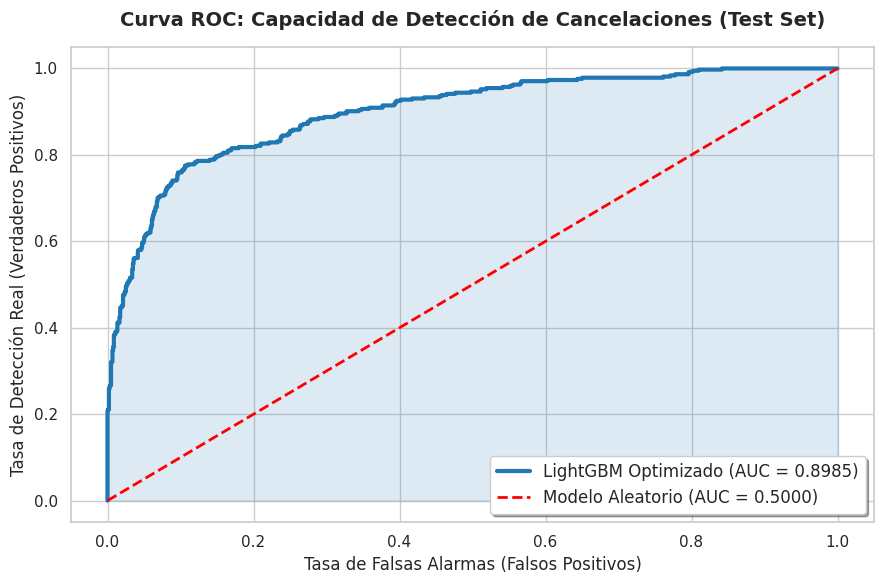

In [28]:
# Cargamos librerías
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import seaborn as sns

print("===== GRÁFICA DE LA CURVA ROC DEL MODEL LIGHTBGM OPTIMIZADO =====")

# Calculamos las coordenadas de la curva matemática
# (Usamos prob_opt_test y roc_auc_opt_test que calculamos en el bloque 3.5)
fpr, tpr, umbrales = roc_curve(y_test, prob_opt_test)

# Configuramos el lienzo y el estilo
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

# Trazamos la línea de nuestro modelo
plt.plot(fpr, tpr, color='#1f77b4', linewidth=3, 
         label=f'LightGBM Optimizado (AUC = {roc_auc_opt_test:.4f})')

#Trazamos la línea del "modelo aleatorio"
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, 
         label='Modelo Aleatorio (AUC = 0.5000)')

# Rellenamos el área bajo la curva (AUC)
plt.fill_between(fpr, tpr, alpha=0.15, color='#1f77b4')

# Agregamos los títulos y etiquetas descriptivas
plt.title('Curva ROC: Capacidad de Detección de Cancelaciones (Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tasa de Falsas Alarmas (Falsos Positivos)', fontsize=12)
plt.ylabel('Tasa de Detección Real (Verdaderos Positivos)', fontsize=12)

# Colocamos la leyenda en la esquina inferior derecha
plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

- El gráfico de la curva ROC representa los buenos resultados del modelo optimizado. La curva se desplaza hacia la esquina superior izquierda, alejándose de la línea de Modelo Aleatorio. Esto demuestra que el modelo es capaz de alcazar una alta tasa de detección de fugas (Verdaderos Positivos) manteniendo al mínimo las falsas alarmas (Falsos Positivos).

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Siempre una visualización es mucho mejor para explicar las diferencias o resultados de lo realizado en tu proyecto, buen trabajo con esta gráfica.
</div>

### 4. Comunicación de resultados

#### 4.1. Evaluación técnica

===== 4.1 EVALUACIÓN TÉCNICA: IMPORTANCIA DE VARIABLES ===


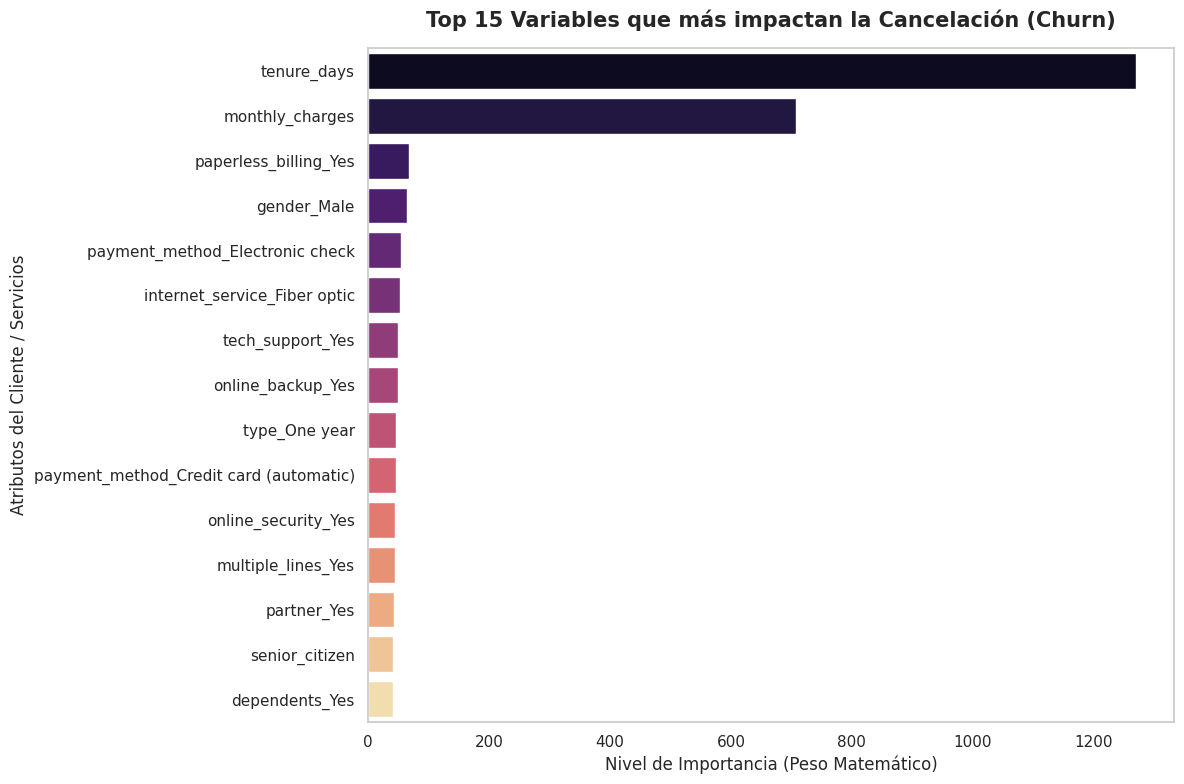

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("===== 4.1 EVALUACIÓN TÉCNICA: IMPORTANCIA DE VARIABLES ===")

importancias = modelo_optimizado.feature_importances_
nombres_variables = X_train_encoded.columns

df_importancia = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
df_top15 = df_importancia.sort_values(by='Importancia', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=df_top15, palette='magma')

plt.title('Top 15 Variables que más impactan la Cancelación (Churn)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Nivel de Importancia (Peso Matemático)', fontsize=12)
plt.ylabel('Atributos del Cliente / Servicios', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Notas:**
- Mediante el atributo *feature_importances_* del modelo *LightGBM*, podemos cuantificar el peso matemático de cada variable en el proceso predictivo. Esto refleja qué tanta ganancia de información (*Information Gain*) aportó cada característica al momento de construir y dividir las ramas de los árboles de decisión.
- Se logró que el modelo hiciera predicciones confiables gracias a que los proceso de limpieza, estandarización y *One-Heat Enconding* fueron bien realizados, evitando meter datos que generaran ruido.

#### 4.2. Informe Estratégico

Tras una evaluación exhaustiva de múltiples algortimos de Machine Learning, el modelo seleccionado para la predicción de cancelación de clientes (*churn*) es *LightGBM* con optimización de parámetros. Este modelo demostró tener la mayor capacidad para identificar patrones de fuga.

El algoritmo superó los estándares exigidos, alcanzando un *ROC-AUC* de 0.8985 en el entorno de prueba. Esto significa que el modelo tiene una precisión cercana al 90% para distinguir entre un cliente leal y uno en riesgo de cancelación. 

**¿Porqué se van los clientes?**
Descubrimos que las decisiones de fuga están fertemente dominadas por factores económicos y de lealtada. Los elementos críticos son:
- ***Antigüedad del cliente (tenure_days):*** El riesgo de cancelación está directamente ligado al tiempo que llevan con la empresa. Se encontró un aumento de cancelaciones en los primeros meses de contratación.
- ***Cargos Mensuales (monthly_charges):*** El costo del servicio es el segundo factor más sensible. El impacto económico influye directamente en la retención.

Basado en los descubrimientos, se sugiere a la Dirección y al Departamento de Marketing implementar las siguientes estrategias:
- **Campañas de fidelización temprana:** Dado que la antigüedad (*tenure*) es el factor número uno, los clientes nuevo son más vulnerables a irse. Se debe crar un programa de incentivos agresivos durante los primeros meses de contratado el servicio para asegurar que el cliente no cancele.
- **Revisin de sensibilidad al precio:** Al ser el cargo mensual (*monthly_charges*) un detonante crítico, el equipo de marketing debe apoyarse en el modelo para ofrecer descuentos personalizados a aquellos cliente que el algortimo marque con alta probabilidad de fuga.

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteración)</b> <a class=“tocSkip”></a>

¡**Buen trabajo con el desarrollo del proyecto Paul**!
    
Realizaste una muy buena exploración de tus datos y planteaste comentarios acertados de los resultados, las métricas utilizadas para tus modelos son las adecuadas.

Recuerda que un buen profesional de datos no sólo debe priorizar la parte técnica sino el impacto que tu habilidad puede traer al negocio, combina tu excelente conocimiento técnico con conocimiento del negocio específico en el que participes y tendrás un perfil muy robusto cómo profesional!
    
Me gustaría dejarte algunas recomendaciones para que resaltes tu perfil profesional en el mundo laboral:
    
- **Exponer los modelos:** Puedes agregar más valor a tu perfil profesional exponiendo los modelos para que puedan ser utilizados en algún demo, esto puedes hacerlo con streamlit y en render.com cómo lo hiciste en un sprint anterior. Pero si quieres ir más allá también podrías investigar y hacerlo utilizando el framework de FastAPI.
- **Herramientas cloud:** Para demostrar un perfil más completo, también podrías utilizar algún servicio cloud cómo AWS y tratar de subir tus modelos entrenados ahí. No tienes que hacerlo a manera de experto, pero siempre es un plus tener conocimiento de estas herramientas.
- **Continúa aprendiendo y practicando:** La práctica hace al maestro, mientras más practiques más errores podrás solucionar y estarás más listo para afrontar problemas reales en un entorno laboral.
    
Saludos y felicidades!
</div>